In [20]:
# libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('ggplot')

from matplotlib.pyplot import figure
from matplotlib.lines import Line2D

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)

1 - Understanding the Data Structure

In [21]:
df = pd.read_csv(
    r'../data/ai_jobs_salaries_clean.csv'
)

print(f'| Rows: {df.shape[0]} | Columns: {df.shape[1]} |')

df.head()

| Rows: 71913 | Columns: 17 |


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN


In [22]:
df.dtypes

work_year                  int64
experience_level          object
employment_type           object
job_title                 object
salary                     int64
salary_currency           object
salary_in_usd              int64
employee_residence        object
remote_ratio               int64
company_location          object
company_size              object
experience_level_label    object
employment_type_label     object
work_mode                 object
salary_outlier_flag         bool
role_family               object
isco_group_hint           object
dtype: object

In [23]:
# are there null values in the company size column?
count_null = df['company_size'].value_counts(dropna = False)

print(count_null)

company_size
M    70110
L     1588
S      215
Name: count, dtype: int64


In [24]:
# assigning a label for the company size
df['company_size_label'] = df['company_size'].map(
    {
        'S': 'Small',
        'M': 'Medium',
        'L': 'Large'
    }
)

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint,company_size_label
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...,Medium
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...,Medium
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians",Medium
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians",Medium
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN,Medium


2 - Verifying the data distribution

In [25]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,71913.000000,7.191300e+04,71913.000000,71913.000000
mean,2024.425153,1.617102e+05,151161.252625,24.569271
std,0.721198,2.872868e+05,77329.594122,42.917779
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,9.640000e+04,96000.000000,0.000000
50%,2025.000000,1.397000e+05,138750.000000,0.000000
75%,2025.000000,1.922000e+05,190315.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [26]:
# analyzing the distribution across company sizes. What is the representation of each one of them?
count_company_size = df['company_size_label'].value_counts()
perc_company_size = round(df['company_size_label'].value_counts(normalize = True) * 100, 1).astype(str) + ' %'

print('-' * 37)
print('| Company Size | Count | Percentage |')

for i in count_company_size.index:
    print(f'| {i:<12} | {count_company_size[i]:<5} | {perc_company_size[i]:<10} |')

print('-' * 37)

-------------------------------------
| Company Size | Count | Percentage |
| Medium       | 70110 | 97.5 %     |
| Large        | 1588  | 2.2 %      |
| Small        | 215   | 0.3 %      |
-------------------------------------


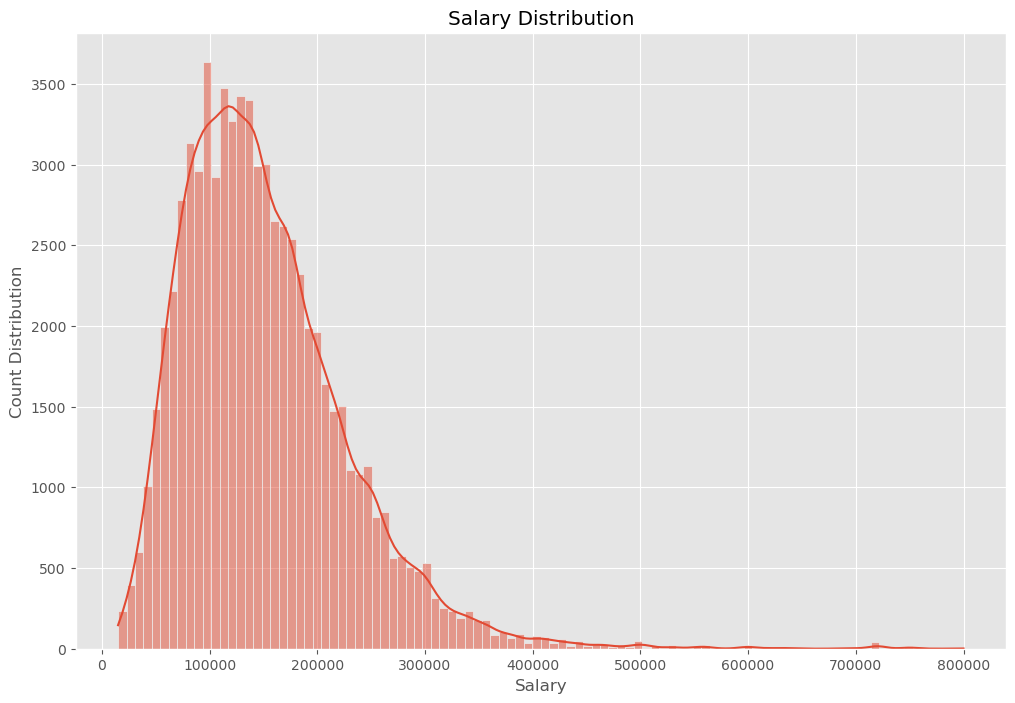

In [27]:
# salary distribution
sns.histplot(
    data = df,
    x = 'salary_in_usd',
    bins = 100,
    kde = True
)

plt.title('Salary Distribution')

plt.xlabel('Salary')
plt.ylabel('Count Distribution')

plt.show()

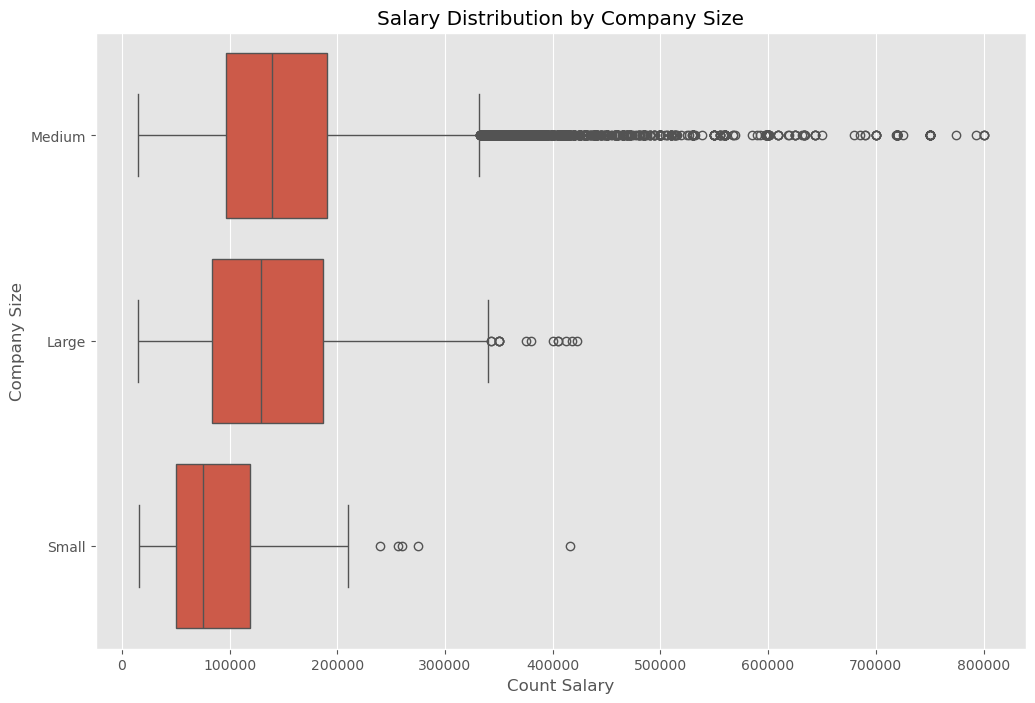

In [28]:
# analyzing the salary distribution across company sizes
sns.boxplot(
    data = df,
    x = 'salary_in_usd',
    y = 'company_size_label'
)

plt.title('Salary Distribution by Company Size')

plt.ylabel('Company Size')
plt.xlabel('Count Salary')

plt.show()

Making a dataset for each size and dropping outliers

In [29]:
# dataset for each size
df_small = df[
    df['company_size_label'] == 'Small'
]

df_medium = df[
    df['company_size_label'] == 'Medium'
]

df_large = df[
    df['company_size_label'] == 'Large'
]

# finding the 25th percentile of the groups
small_25 = np.percentile(df_small['salary_in_usd'], 25)
medium_25 = np.percentile(df_medium['salary_in_usd'], 25)
large_25 = np.percentile(df_large['salary_in_usd'], 25)

# finding the 75th percentile of the groups
small_75 = np.percentile(df_small['salary_in_usd'], 75)
medium_75 = np.percentile(df_medium['salary_in_usd'], 75)
large_75 = np.percentile(df_large['salary_in_usd'], 75)

# calculating the small boundaries
small_lb = small_25 - ((small_75 - small_25) * 1.5)
if small_lb < 0: small_lb = 0

small_ub = small_75 + ((small_75 - small_25) * 1.5)

# calculating the medium boundaries
medium_lb = medium_25 - ((medium_75 - medium_25) * 1.5)
if medium_lb < 0: medium_lb = 0

medium_ub = medium_75 + ((medium_75 - medium_25) * 1.5)

# calculating the large boundaries
large_lb = large_25 - ((large_75 - large_25) * 1.5)
if large_lb < 0: large_lb = 0

large_ub = large_75 + ((large_75 - large_25) * 1.5)

# print configuration
small_iqr_label = f'| Small 25th Percentil: {small_25:<9} | Small 75th Percentil: {small_75:<9} |'
medium_iqr_label = f'| Medium 25th Percentil: {medium_25:<8} | Medium 75th Percentil: {medium_75:<8} |'
large_iqr_label = f'| Large 25th Percentil: {large_25:<9} | Large 75th Percentil: {large_75:<9} |'

small_bnd_label = f'| Small Lower Bound: {small_lb:<12} | Small Uper Bound: {small_ub:<13} |'
medium_bnd_label = f'| Medium Lower Bound: {medium_lb:<11} | Medium Uper Bound: {medium_ub:<12} |'
large_bnd_label = f'| Large Lower Bound: {large_lb:<12} | Large Uper Bound: {large_ub:<13} |'

print("-" * len(medium_iqr_label))
print(small_iqr_label)
print(medium_iqr_label)
print(large_iqr_label)
print("-" * len(medium_iqr_label))
print(small_bnd_label)
print(medium_bnd_label)
print(large_bnd_label)
print("-" * len(medium_iqr_label))

---------------------------------------------------------------------
| Small 25th Percentil: 50000.0   | Small 75th Percentil: 118823.5  |
| Medium 25th Percentil: 96600.0  | Medium 75th Percentil: 190791.5 |
| Large 25th Percentil: 84053.0   | Large 75th Percentil: 187185.5  |
---------------------------------------------------------------------
| Small Lower Bound: 0            | Small Uper Bound: 222058.75     |
| Medium Lower Bound: 0           | Medium Uper Bound: 332078.75    |
| Large Lower Bound: 0            | Large Uper Bound: 341884.25     |
---------------------------------------------------------------------


In [30]:
# filtering values within the boundaries range (small table)
df_small = df_small[
    (df_small['salary_in_usd'] >= small_lb) & (df_small['salary_in_usd'] <= small_ub)
]

df_small.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,210.000000,2.100000e+02,210.000000,210.000000
mean,2022.319048,2.606123e+05,83167.861905,65.714286
std,1.358341,9.177901e+05,47901.368361,41.683637
min,2020.000000,1.400000e+04,15809.000000,0.000000
25%,2021.000000,5.000000e+04,50000.000000,50.000000
50%,2022.000000,8.000000e+04,71089.500000,100.000000
75%,2023.000000,1.250000e+05,115000.000000,100.000000
max,2025.000000,8.500000e+06,210000.000000,100.000000


In [31]:
# filtering values within the boundaries range (medium table)
df_medium = df_medium[
    (df_medium['salary_in_usd'] >= medium_lb) & (df_medium['salary_in_usd'] <= medium_ub)
]

df_medium.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,68383.000000,6.838300e+04,68383.000000,68383.000000
mean,2024.447407,1.528330e+05,145118.698346,24.615767
std,0.679363,2.408843e+05,64722.551620,43.047749
min,2020.000000,1.440000e+04,15000.000000,0.000000
25%,2024.000000,9.550000e+04,95300.000000,0.000000
50%,2025.000000,1.376000e+05,137000.000000,0.000000
75%,2025.000000,1.870000e+05,186000.000000,0.000000
max,2025.000000,3.000000e+07,332000.000000,100.000000


In [32]:
# filtering values within the boundaries range (large table)
df_large = df_large[
    (df_large['salary_in_usd'] >= large_lb) & (df_large['salary_in_usd'] <= large_ub)
]

df_large.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,1574.000000,1.574000e+03,1574.000000,1574.000000
mean,2023.627700,2.613481e+05,135723.320839,28.970775
std,1.331279,1.023174e+06,68617.577342,41.537004
min,2020.000000,1.440000e+04,15000.000000,0.000000
25%,2023.000000,9.120000e+04,83898.000000,0.000000
50%,2024.000000,1.360000e+05,129100.000000,0.000000
75%,2025.000000,2.000000e+05,185000.000000,50.000000
max,2025.000000,3.040000e+07,340300.000000,100.000000


In [33]:
# mergering the filtered datasets
df_companie_size = pd.concat(
    [
       df_small,
       df_medium,
       df_large 
    ],
    ignore_index = True
)

print(f'| Rows: {df_companie_size.shape[0]} | Columns: {df_companie_size.shape[1]} |')
df_companie_size.head()

| Rows: 70167 | Columns: 18 |


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint,company_size_label
0,2025,EN,FT,Fraud Data Analyst,75000,CAD,53571,CA,100,CA,S,Entry-level,Full-time,Remote,False,Data Analyst,Business services and administration managers,Small
1,2025,EN,FT,Admin & Data Analyst,52000,USD,52000,US,0,US,S,Entry-level,Full-time,On-site,False,Data Analyst,Business services and administration managers,Small
2,2025,SE,FT,Data Engineer 4,120000,USD,120000,ES,50,ES,S,Senior-level,Full-time,Hybrid,False,Data Engineer,Software and applications developers,Small
3,2025,SE,FT,Data Scientist Manager,40000,EUR,42105,GR,100,GR,S,Senior-level,Full-time,Remote,False,Data Scientist,"Mathematicians, actuaries and statisticians",Small
4,2025,SE,FT,AI Engineer,77000,EUR,81052,BE,50,BE,S,Senior-level,Full-time,Hybrid,False,AI Engineer,Software and applications developers,Small


In [34]:
df_companie_size.to_csv(r'../data/df_company_sizes.csv')

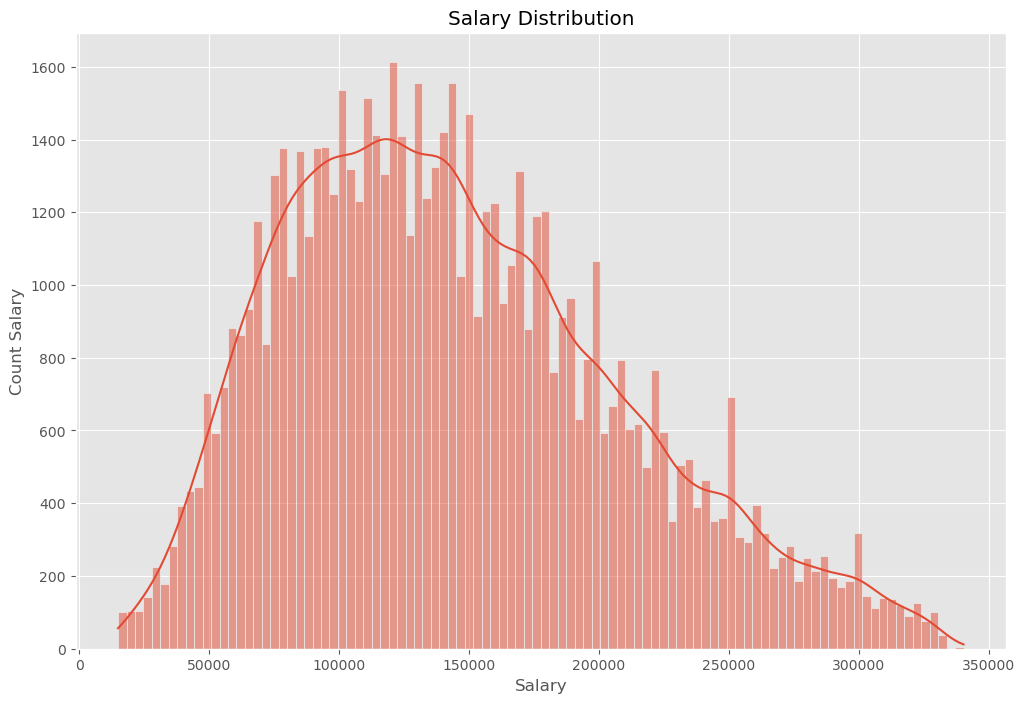

In [35]:
# checking the new data distribution
sns.histplot(
    data = df_companie_size,
    x = 'salary_in_usd',
    bins = 100,
    kde = True
)

plt.title('Salary Distribution')

plt.ylabel('Count Salary')
plt.xlabel('Salary')

plt.show()

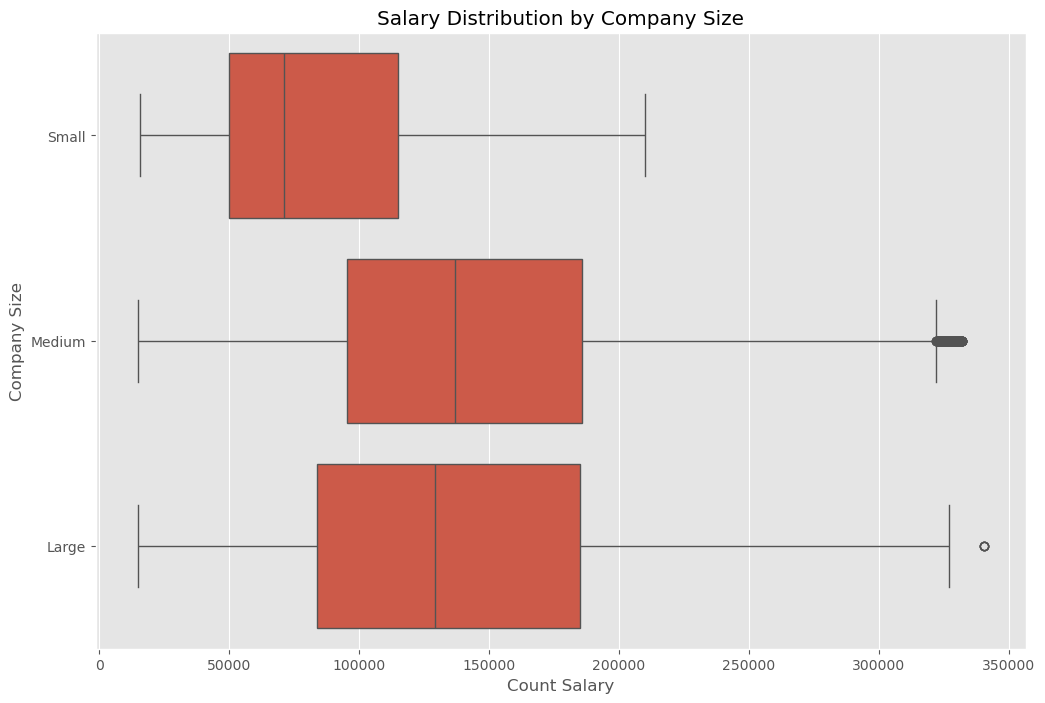

In [36]:
# checking the salary distribution across sizes
sns.boxplot(
    data = df_companie_size,
    x = 'salary_in_usd',
    y = 'company_size_label'
)

plt.title('Salary Distribution by Company Size')

plt.ylabel('Company Size')
plt.xlabel('Count Salary')

plt.show()

3 - Applying the test

**Experiment 2:** Is there a significant salary difference across company sizes?

**Variables:** 
* Salary (USD); 
* Company Size (Small, Medium and Small)

**Test Parameters:**
* **Null Hypothesis (H0):** Company size has no effect on average salary
* **Alternative Hypothesis (H1):** At least one company size has a different population mean salary
* **Alpha:** 0.05

In [37]:
# applying the Kruskall-Wallis test
alpha = 0.05

stat, p_value = stats.kruskal(
    df_small['salary_in_usd'], 
    df_medium['salary_in_usd'],
    df_large['salary_in_usd']
)

# test result
if p_value < alpha:
    print('Reject the null hyphotesis (H0): There is statistically significant among small, medium and large companies')
else:
    print('Fail to reject the Null hypothesis (H0) - There is no statiscally difference among small, medium and large companies')

Reject the null hyphotesis (H0): There is statistically significant among small, medium and large companies


In [38]:
print(p_value)

3.435001396973575e-50


Since the null hypothesis was rejected, we are going to find the group with the highest variance, and a Post-Hoc test is going to be performed to evaluate this.

In [39]:
# test parameters
alpha = 0.05
comparisons = 3
adjusted_alpha = alpha / comparisons

# executing the test
stat_sm, p_value_sm = stats.mannwhitneyu(df_small['salary_in_usd'], df_medium['salary_in_usd'])
stat_sl, p_value_sl = stats.mannwhitneyu(df_small['salary_in_usd'], df_large['salary_in_usd'])
stat_ml, p_value_ml = stats.mannwhitneyu(df_medium['salary_in_usd'], df_large['salary_in_usd'])

result = {
    'Small vs. Medium': p_value_sm,
    'Small vs. Large': p_value_sl,
    'Medium vs. Large': p_value_ml
}

# printing the result 
for comparison, p_val in result.items():
    if p_val < adjusted_alpha:
        print(f'[{comparison}] Reject Null Hypothesis (H0): Significant pay gap (p = {p_val:.3e})')
    else:
        print(f"[{comparison}] Fail to Reject H0: No significant pay gap (p = {p_val:.3e})")

[Small vs. Medium] Reject Null Hypothesis (H0): Significant pay gap (p = 2.570e-45)
[Small vs. Large] Reject Null Hypothesis (H0): Significant pay gap (p = 1.589e-27)
[Medium vs. Large] Reject Null Hypothesis (H0): Significant pay gap (p = 4.864e-08)
